# Cadre Optimizer Benchmark

Compares **ADABK0** and **ADABK5** (with `cooldown=10`) against three reference solvers on a
10-dimensional noisy Rosenbrock function.


In [1]:
import time

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import pandas as pd
from cadre import minimize

jax.config.update("jax_enable_x64", True)

# ── Problem parameters ────────────────────────────────────────────────────────
N_DIMS = 10
NOISE_SCALE = 1.5  # additive Gaussian noise on the function value
MAX_ITER = 2000
LOWER, UPPER = -5.0, 10.0
X0 = jnp.array([-1.2, 1.0] * (N_DIMS // 2))  # classic starting point
NOISE_KEY = jax.random.PRNGKey(42)

/home/wassim/micromamba/envs/fg/lib/python3.11/site-packages/jaxlib/plugin_support.py:91: RuntimeWarning: JAX plugin jax_cuda12_plugin version 0.9.1 is installed, but it is not compatible with the installed jaxlib version 0.9.2, so it will not be used.
  warnings.warn(


## Objective function

The **noisy Rosenbrock** adds a fixed-seed Gaussian perturbation to the clean function value.
This gives a reproducible but non-zero noise floor that exercises solver robustness.

In [2]:
def noisy_rosenbrock(x):
    """10-D Rosenbrock + additive Gaussian noise (fixed seed)."""
    base = jnp.sum(100.0 * (x[1:] - x[:-1] ** 2) ** 2 + (1 - x[:-1]) ** 2)
    noise = jax.random.normal(NOISE_KEY) * NOISE_SCALE
    return base + noise


print(f"f(x0)  = {noisy_rosenbrock(X0):.4e}")
print(f"f(x*)  = {noisy_rosenbrock(jnp.ones(N_DIMS)):.4e}  (global minimum at x=1)")

f(x0)  = 2.0567e+03
f(x*)  = -2.7707e-01  (global minimum at x=1)


## Solver configurations

In [15]:
SOLVERS = [
    {"name": "ADABK0", "solver": "ADABK0", "options": {"cooldown": 5, "min_steps": 5}},
    {"name": "ADABK5", "solver": "ADABK5", "options": {"cooldown": 5, "min_steps": 5}},
    {"name": "scipy_cobyqa", "solver": "scipy_cobyqa", "options": {}},
    {"name": "scipy_tnc", "solver": "scipy_tnc", "options": {}},
    {"name": "optax_lbfgs", "solver": "optax_lbfgs", "options": {}},
]

## Benchmark

In [16]:
def run_benchmark(cfg):
    opts = cfg["options"] if cfg["options"] else None
    t0 = time.perf_counter()
    _params, state = minimize(
        noisy_rosenbrock,
        X0,
        solver_name=cfg["solver"],
        options=opts,
        max_iter=MAX_ITER,
        lower_bound=LOWER,
        upper_bound=UPPER,
        atol=1e-12,
        rtol=1e-12,
    )
    elapsed = time.perf_counter() - t0
    return {
        "solver": cfg["name"],
        "iterations": int(state.iter_num),
        "final_loss": float(state.best_loss),
        "time_s": elapsed,
    }

In [17]:
%%capture _cap
results = [run_benchmark(cfg) for cfg in SOLVERS]

In [18]:
for r in results:
    print(
        f"{r['solver']:<16}  iters={r['iterations']:>5}   loss={r['final_loss']:>12.3e}   t={r['time_s']:.1f}s"
    )

ADABK0            iters= 2000   loss=  -2.771e-01   t=1.8s
ADABK5            iters= 2000   loss=  -2.771e-01   t=1.6s
scipy_cobyqa      iters=  736   loss=   3.710e+00   t=11.6s
scipy_tnc         iters=   13   loss=   2.821e+00   t=1.2s
optax_lbfgs       iters=  150   loss=  -2.771e-01   t=1.2s


## Results

In [14]:
df = pd.DataFrame(results).set_index("solver")
df_display = df.copy()
df_display["final_loss"] = df["final_loss"].map("{:.3e}".format)
df_display["time_s"] = df["time_s"].map("{:.2f} s".format)
df_display

,iterations,final_loss,time_s
solver,,,
ADABK0,2000,-2.771e-01,1.81 s
ADABK5,2000,-2.771e-01,1.62 s
scipy_cobyqa,736,3.710e+00,11.28 s
scipy_tnc,13,2.821e+00,1.15 s
optax_lbfgs,150,-2.771e-01,1.14 s


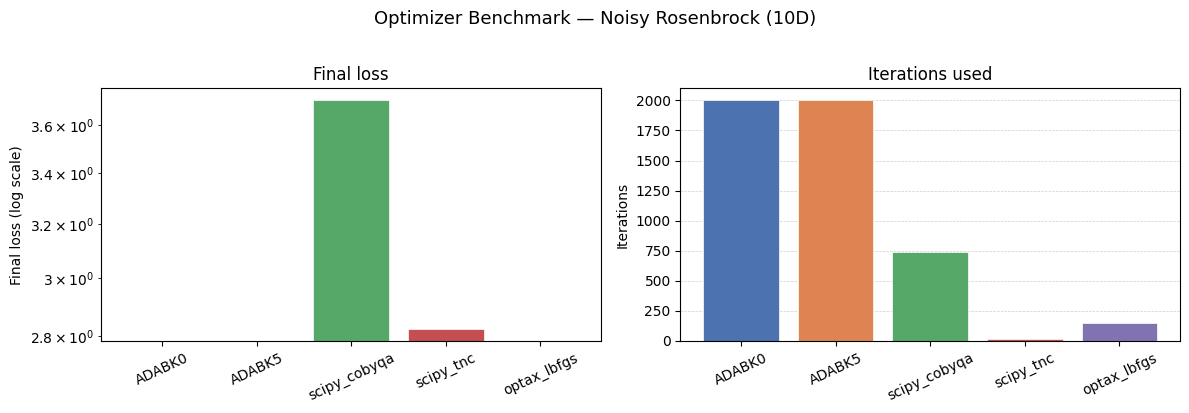

In [8]:
PALETTE = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B2"]
solvers = df.index.tolist()
colors = {s: PALETTE[i] for i, s in enumerate(solvers)}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Optimizer Benchmark — Noisy Rosenbrock (10D)", fontsize=13, y=1.02)

# ── Final loss (log scale) ────────────────────────────────────────────────────
bar_colors = [colors[s] for s in solvers]
ax1.bar(solvers, df["final_loss"], color=bar_colors, edgecolor="white", linewidth=0.5)
ax1.set_yscale("log")
ax1.set_ylabel("Final loss (log scale)")
ax1.set_title("Final loss")
ax1.tick_params(axis="x", rotation=25)
ax1.grid(axis="y", linestyle="--", linewidth=0.5, alpha=0.6)
ax1.set_axisbelow(True)

# ── Iterations used ───────────────────────────────────────────────────────────
ax2.bar(solvers, df["iterations"], color=bar_colors, edgecolor="white", linewidth=0.5)
ax2.set_ylabel("Iterations")
ax2.set_title("Iterations used")
ax2.tick_params(axis="x", rotation=25)
ax2.grid(axis="y", linestyle="--", linewidth=0.5, alpha=0.6)
ax2.set_axisbelow(True)

fig.tight_layout()
plt.show()

## Notes

- **ADABK0 vs ADABK5**: ADABK0 never releases active constraints; ADABK5 releases up to 50 % per step.
  A lower final loss for ADABK5 indicates that constraint release helps escape the box boundary.
- **cooldown=10**: both ADABK solvers wait at least 10 steps after any release before considering
  termination, preventing premature stopping on a still-improving trajectory.
- **scipy_cobyqa / scipy_tnc**: gradient-free and Newton-CG reference baselines.
  They are self-conditioned and do not require `precondition=True`.
- **optax_lbfgs**: JAX-native L-BFGS with zoom linesearch — typically the most efficient
  gradient-based baseline on smooth problems.